## PaleoExfiltration Model Code (Retreat-Readvance Time Series) ##

##### This code has been adapted from Robel et al. (2023). 

### Load in packages to run hydromechanical model and plot

In [1]:
# Load in necessary packages 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as spr
from scipy.sparse.linalg import inv
from pyproj import Proj, transform

In [2]:
# Loading in the interpolated data frame produced in the PreExfiltration.ipynb or PreExfiltrationSpline.ipynb
file_path ='retreatreadvancetimeseries.csv'
interpolated_df = pd.read_csv(file_path)

# Calculate the duration for each site
duration_tf = interpolated_df.groupby('Site ').agg(
    Start_Age=('Age', 'max'),
    End_Age=('Age', 'min'),
    Duration=('Age', lambda x: x.max() - x.min())
).reset_index()

# Display the first few rows of the duration data
duration_tf.head()

,Site,Start_Age,End_Age,Duration
0,1,8.1,0.0,8.1


In [3]:
# Set the site number 
site = 1 # Specify the site number
site_data = interpolated_df[interpolated_df['Site '] == site]

# Interpolate thickness data to match the time steps
f_interp = np.interp(t/year, site_data['Age'], site_data['Thickness'])

# Assign interpolated thickness values to hbc_sfc
hbc_sfc[:] = f_interp

# Extract latitude and longitude
site_lat = site_data['latitude'].values[0]  # Latitude of the site
site_lon = site_data['longitude'].values[0]  # Longitude of the site

NameError: name 't' is not defined

### Parameters

In [6]:
intSave=100
year = 3600*24*365

#xi is dimensionless loading efficiency(Skempton's constant)
xi = 0.2

#rhoi is the density of glacier ice (kg/m3)
rhoi = 920

#rhow is density of water
rhow = 1000

#g is acceleration due to gravity (m/s2)
g = 9.81

#mu_w is the viscosity of water (Pa*s)
mu_w = 1e-3

#S is sediment specific storage capacity (m-1)
S = 1e-4

#permeability
perm=1e-11

#K_t is the hydraulic conductivity (function of perm which we assume stays constant over time)
K_t = perm*rhow*g/mu_w

#Can't find this in the paper, but assuming it has somthing to do 
D = K_t/S

#H_init is the initial thickness of overlying glacier ice (m)
h_init = site_data['Thickness'].max()

# Calculate dh as the total change in ice thickness for the site
dh = site_data['Thickness'].max() - site_data['Thickness'].min()

# Grids and pre-allocation

In [7]:
# Define the length of the domain (L) in meters. In this case, it's 40 km (40,000 meters).
L = 40e3

# Set the number of grid points (nx) to 1001
nx = int(1e3 + 1) # Make it smaller to make the grid coarser 

# Generate a linearly spaced array (x) from 0 to L, with nx points.
# This array represents the spatial coordinates across the domain.
x = np.linspace(0, L, num=nx)

# Calculate the grid spacing (dx) as the difference between consecutive points in the x array.
dx = x[1] - x[0]

# Set a diffusion coefficient (C_D) to 1, which is a dimensionless parameter used in the time step calculation.
C_D = 1

# Calculate the time step (dt) based on the grid spacing (dx) and a given diffusion constant (D).
# The time step is determined by the stability criterion for the diffusion equation.
dt = (dx**2) * C_D / D # Make the time step longer by changing nx.

# Define the total simulation time (tf) in seconds
tf = (site_data['Age'].max() - site_data['Age'].min()) #How many years we want the simulation to be 

# Calculate the total number of time steps (nt) based on the total time (tf) and the time step (dt).
# The result is rounded and then increased by 1 to account for the initial time step.
#nt = int(np.round(tf / dt) + 1)
nt = len(site_data)

# Generate a linearly spaced array (t) from 0 to tf, with nt points.
# This array represents the time steps across the entire simulation period.
#t = np.linspace(0, tf, num=nt) # Vector that goes over the years you want to simulate. 
t = site_data['Age'].values

# Initialize the hydraulic pressure head (h) within the sediment.
# The initial head (h_init) is scaled by the ratio of ice density (rhoi) to water density (rhow)
# and is uniformly applied across the entire domain (nx points).
h = h_init * (rhoi / rhow) * np.ones(nx)

# Create an array (h_all) to store the hydraulic pressure head values at each time step for the entire domain.
# The array has dimensions [nx, int(nt/intSave)+1], where intSave is a variable controlling the frequency of saving data.
h_all = np.zeros([nx, int(nt/intSave) + 1])

# Store the initial hydraulic pressure head (h) in the first column of h_all.
h_all[:, 0] = h


# Specify time-dependent load change

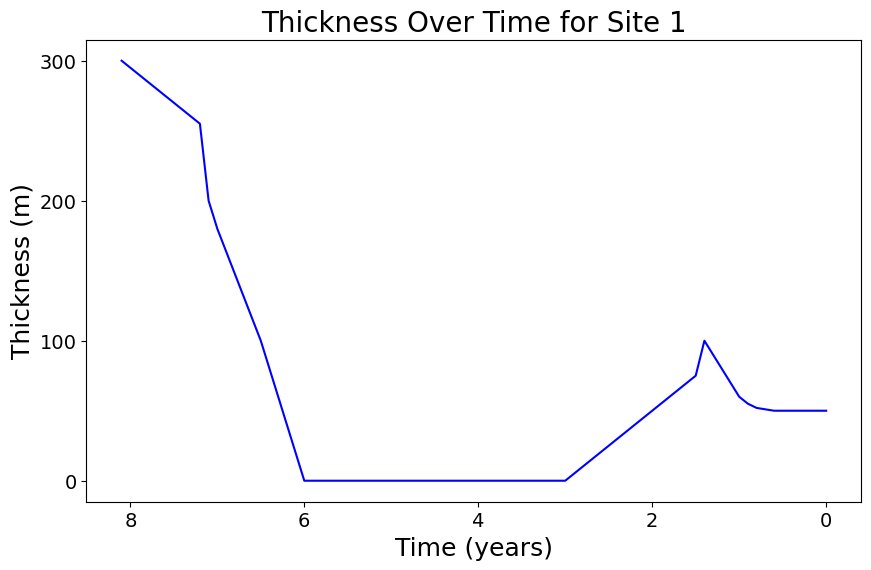

In [8]:
#this is where we'll change the time domain to geologic timescales-so eventually 20,000 years 
#ramp_time = 20 #in years

# Initialize an array to store the ice surface height at different time steps
#hbc_sfc  = np.zeros(int(nt)); #nt is the total number of time steps 
hbc_sfc = site_data['Thickness'].values

#change in ice surface height with time
dhdt = np.zeros_like(hbc_sfc)

# Create boolean masks to identify the time before and after the ramp time
#bramp_bool = t < ramp_time*year #before ramp time
#aramp_bool = t >= ramp_time*year #after ramp time 

# For times before the ramp, linearly decrease the ice surface height from initial height h_init to h_init - dh
#hbc_sfc[bramp_bool] = np.linspace(h_init,h_init-dh,np.count_nonzero(bramp_bool, axis=None))

# For times after the ramp, keep the ice surface height constant at h_init - dh
#hbc_sfc[aramp_bool] = h_init-dh;

# Calculate the rate of change of ice surface height over time by taking the difference between consecutive time steps
dhdt[1:] = np.diff(hbc_sfc)/dt

#Optional: Uncommenting the following lines would instead set dhdt to a linear decrease over the ramp period
#dhdt[bramp_bool] = -np.linspace(0,2*dh/ramp_time,np.count_nonzero(bramp_bool, axis=None))/year
#hbc_sfc = h_init + np.cumsum(dhdt*dt)

plt.figure(figsize=(10, 6))
plt.plot(site_data['Age'], site_data['Thickness'], color='blue')
plt.xlabel('Time (years)', fontsize=18)  # Increase the font size
plt.ylabel('Thickness (m)', fontsize=18)  # Increase the font size
plt.title(f'Thickness Over Time for Site {site}', fontsize=20)  # Increase the font size
plt.gca().invert_xaxis()  # Invert x-axis so that time decreases to the right

# Customize ticks
plt.xticks(fontsize=14)  # Set x-axis tick font size
plt.yticks(fontsize=14)  # Set y-axis tick font size

# Reduce the number of ticks
plt.locator_params(axis='x', nbins=5)  # Fewer ticks on the x-axis
plt.locator_params(axis='y', nbins=5)  # Fewer ticks on the y-axis

plt.show()

# Solve with Crank-Nicolson method

In [9]:
# Initialize a 3x(nx) matrix filled with zeros to store the diagonals for the left-side matrix (Ml)
Mld = np.zeros([3,nx])

# Set the first and third rows of the matrix to be -0.5*C_D for all columns
Mld[0, :] = -0.5 * C_D * np.ones(nx)  # Upper diagonal
Mld[2, :] = -0.5 * C_D * np.ones(nx)  # Lower diagonal

# Set the second row of the matrix to be (1+C_D) for all columns
Mld[1, :] = (1 + C_D) * np.ones(nx)  # Main diagonal

# Create a sparse matrix (Ml) using the diagonals in Mld with offsets -1, 0, and 1
Ml = spr.spdiags(Mld, [-1, 0, 1], nx, nx)

# Convert the sparse matrix to a compressed sparse column format for efficient arithmetic and matrix-vector operations
Ml = spr.csc_matrix(Ml)

# Modify specific elements in the sparse matrix to enforce boundary conditions
Ml[-1, -1] = 1 + 0.5 * C_D  # Adjust the last element on the main diagonal
Ml[0, 1] = 0  # Set the first off-diagonal element to zero
Ml[0, 0] = 1  # Set the first element on the main diagonal to one

# Compute the inverse of the left-side matrix (Ml)
iMl = inv(Ml)

# Initialize a 3x(nx) matrix filled with zeros to store the diagonals for the right-side matrix (Mr)
Mrd = np.zeros([3, nx])

# Set the first and third rows of the matrix to be 0.5*C_D for all columns
Mrd[0, :] = 0.5 * C_D * np.ones(nx)  # Upper diagonal
Mrd[2, :] = 0.5 * C_D * np.ones(nx)  # Lower diagonal

# Set the second row of the matrix to be (1-C_D) for all columns
Mrd[1, :] = (1 - C_D) * np.ones(nx)  # Main diagonal

# Create a sparse matrix (Mr) using the diagonals in Mrd with offsets -1, 0, and 1
Mr = spr.spdiags(Mrd, [-1, 0, 1], nx, nx)

# Convert the sparse matrix to a compressed sparse column format for efficient arithmetic and matrix-vector operations
Mr = spr.csc_matrix(Mr)

# Modify specific elements in the sparse matrix to enforce boundary conditions
Mr[-1, -1] = 1 - 0.5 * C_D  # Adjust the last element on the main diagonal
Mr[0, 1] = 0  # Set the first off-diagonal element to zero
Mr[0, 0] = 1  # Set the first element on the main diagonal to one

/opt/anaconda3/envs/lgmgroundwater/lib/python3.9/site-packages/scipy/sparse/_index.py:108: SparseEfficiencyWarning: Changing the sparsity structure of a csc_matrix is expensive. lil_matrix is more efficient.
  self._set_intXint(row, col, x.flat[0])


In [10]:
# Loop through each time step from 0 to nt-2 (nt-1 in zero-indexed Python)
for k in np.arange(nt-1):
    # Create a copy of the current ice thickness (h) and reshape it into a column vector (nx, 1)
    hm = h
    hm.shape = (nx, 1)

    # Apply boundary condition: Set the surface height at the first grid point to the surface height at this time step
    # adjusted by the ratio of ice density (rhoi) to water density (rhow)
    h[0] = hbc_sfc[k] * (rhoi / rhow)

    # Initialize a source vector (Svec) with zeros, used to apply the source term from the thinning rate
    Svec = np.zeros([nx, 1])

    # Apply the source term (related to thinning rate) to the interior points of the grid
    Svec[1:-2] = dt * xi * (rhoi / rhow) * dhdt[k]

    # Compute the new ice thickness (hnew) by applying the inverse of the left-side matrix (iMl)
    # to the matrix-vector product of the right-side matrix (Mr) and the current ice thickness (hm), 
    # and adding the source term vector (Svec)
    hnew = iMl.dot(Mr.dot(hm) + Svec)

    # Save the computed ice thickness at intervals specified by intSave
    if k % intSave == 0:
        h_all[:, int(k/intSave)] = np.transpose(hnew)

    # Update the ice thickness (h) to the newly computed values for the next iteration
    h = hnew

# Plot numerical against analytical solution (Figure 2)

In [11]:
# # Calculate the surface flux (sfc_flux) by taking the difference between the first two layers of the ice thickness (h_all)
# # and multiplying by the thermal conductivity (K_t) divided by the grid spacing (dx).
# # The result is transposed to match the expected shape for further use.
# sfc_flux = np.transpose(K_t * (h_all[0, :] - h_all[1, :]) / dx)

# # Calculate the analytical surface flux (sflux_an) based on the thinning rate (dhdt),
# # the thermal conductivity (K_t), a scaling factor (S), and the current time (t).
# # This formula assumes a simplified analytical model for heat transfer in the ice.
# sflux_an = 2 * (1 - xi) * (rhoi / rhow) * dhdt[1] * (K_t * S * t / np.pi) ** 0.5

# # Calculate the analytical surface flux for a small time increment (sflux_an_delta),
# # which represents the surface flux at a specific time step based on the thinning rate (dh),
# # the thermal conductivity (K_t), a scaling factor (S), and the current time (t).
# sflux_an_delta = (1 - xi) * (rhoi / rhow) * dh * (K_t * S / (np.pi * t)) ** 0.5

# # Extract a subset of the time array (tsub) at intervals specified by intSave.
# # This is used to reduce the number of time points when plotting or analyzing the data.
# tsub = t[0:-1:intSave]

# # Create a boolean mask (t_bramp) to identify time points before the ramp period.
# # This is used to differentiate between time periods in the simulation.
# #t_bramp = t < ramp_time * year

# Load in packages to extract relevant field and map exfiltration predictions

In [12]:
import xarray as xr
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.ticker as mticker
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.colors as colors
import cmocean
import scipy.io as sio
import geopandas as gpd
import rioxarray
import zipfile

### Calculate Exfiltration Prediction (plus plot)

In [35]:
# Constants
year = 3600 * 24 * 365  # seconds in a year
rhoi = 920  # density of glacier ice (kg/m3)
rhow = 1000  # density of water (kg/m3)
g = 9.81  # acceleration due to gravity (m/s2)
mu_w = 1e-3  # viscosity of water (Pa*s)
perm = 1e-15  # permeability (m^2)
K_t = perm * rhow * g / mu_w  # hydraulic conductivity (m/s)
S = 1e-4  # sediment specific storage capacity (m-1)
xi = 0.2  # Skempton's constant (dimensionless)
deltat = (site_data['Age'].max() - site_data['Age'].min()) # time increment based on the site's age range

# Calculate dhdt (rate of change of ice thickness)
dhdt = np.gradient(site_data['Thickness'], site_data['Age'])

# Calculate the exfiltration rate for the selected site
exfil_analytic = 2 * (1 - xi) * (rhoi / rhow) * dhdt * (K_t * S * deltat / np.pi) ** 0.5
exfil_value = exfil_analytic * 1000  # Convert to mm/yr

# # Plot the exfiltration rate over time
# plt.figure(figsize=(10, 6))
# plt.plot(site_data['Age'], exfil_value, 'o-', color='blue')
# plt.xlabel('Time (years)', fontsize=18)  # Increase the font size
# plt.ylabel('Exfiltration Rate (mm/yr)', fontsize=18)  # Increase the font size
# plt.title(f'Exfiltration Rate for Site {site}', fontsize=20)  # Increase the font size
# plt.gca().invert_xaxis()  # Invert x-axis so that time decreases to the right

# # Customize ticks
# plt.xticks(fontsize=14)  # Set x-axis tick font size
# plt.yticks(fontsize=14)  # Set y-axis tick font size

# # Reduce the number of ticks
# plt.locator_params(axis='x', nbins=5)  # Fewer ticks on the x-axis
# plt.locator_params(axis='y', nbins=5)  # Fewer ticks on the y-axis

# plt.legend()
# plt.show()

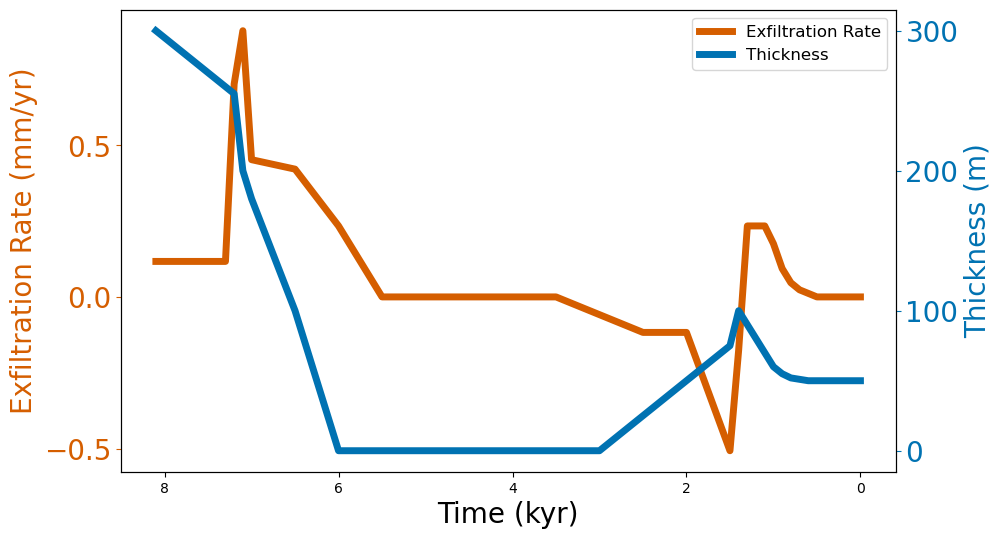

In [36]:
# Create a figure and axis
fig, ax1 = plt.subplots(figsize=(10, 6))

# Set a consistent line width
line_width = 5

# Plot the exfiltration rate on the primary y-axis without circles
line1, = ax1.plot(site_data['Age'], exfil_value, '-', color="#D55E00", label='Exfiltration Rate', linewidth=line_width)
ax1.set_xlabel('Time (kyr)', fontsize=20)
ax1.set_ylabel('Exfiltration Rate (mm/yr)', fontsize=20, color="#D55E00")
ax1.tick_params(axis='y', labelsize=20, colors="#D55E00")
ax1.invert_xaxis()  # Invert x-axis so that time decreases to the right
ax1.locator_params(axis='x', nbins=5)  # Fewer ticks on the x-axis
ax1.locator_params(axis='y', nbins=5)  # Fewer ticks on the y-axis

# Create a secondary y-axis for thickness
ax2 = ax1.twinx()
line2, = ax2.plot(site_data['Age'], site_data['Thickness'], color="#0072B2", label='Thickness', linewidth=line_width)
ax2.set_ylabel('Thickness (m)', fontsize=20, color="#0072B2")
ax2.tick_params(axis='y', labelsize=20, colors="#0072B2")
ax2.locator_params(axis='y', nbins=5)  # Fewer ticks on the y-axis

# Combine legends and place it in the upper right
lines = [line1, line2]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='upper right', fontsize=12)

# Set title
plt.title(f'', fontsize=20)
plt.savefig("exfiltrationcomplexperm15.pdf", format="pdf", dpi=300, bbox_inches="tight")

plt.show()

In [37]:
import numpy as np

# Convert to arrays (in case they're pandas objects)
exfil_arr = np.asarray(exfil_value)
age_arr = np.asarray(site_data['Age'])

# Index of maximum exfiltration
imax = np.nanargmax(exfil_arr)

max_exfil = exfil_arr[imax]
max_age = age_arr[imax]

# Optional: define a time interval (between neighboring points)
if 0 < imax < len(age_arr) - 1:
    time_interval = (age_arr[imax + 1], age_arr[imax - 1])
else:
    time_interval = (max_age, max_age)

print(f"Max exfiltration rate: {max_exfil:.3f} mm/yr")
print(f"Occurs at age: {max_age:.2f} kyr")
print(f"Time interval: {time_interval[0]:.2f}–{time_interval[1]:.2f} kyr")


Max exfiltration rate: 0.878 mm/yr
Occurs at age: 7.10 kyr
Time interval: 7.00–7.20 kyr


In [38]:
# Convert to arrays (in case they're pandas objects)
exfil_arr = np.asarray(exfil_value)
age_arr = np.asarray(site_data['Age'])

# Index of minimum (most negative) exfiltration
imin = np.nanargmin(exfil_arr)
min_exfil = exfil_arr[imin]
min_age = age_arr[imin]

# Define time interval using neighboring points
if 0 < imin < len(age_arr) - 1:
    time_interval = (age_arr[imin + 1], age_arr[imin - 1])
else:
    time_interval = (min_age, min_age)

print(f"Most negative exfiltration rate: {min_exfil:.3f} mm/yr")
print(f"Occurs at age: {min_age:.2f} kyr")
print(f"Time interval: {time_interval[0]:.2f}–{time_interval[1]:.2f} kyr")


Most negative exfiltration rate: -0.507 mm/yr
Occurs at age: 1.50 kyr
Time interval: 1.40–2.00 kyr
